# Wykorzystanie algorytmu XGBoost w predykcji odpływu klientów (Telco Customer Churn)

Ostatnim modelem analizowanym w ramach projektu jest **XGBoost**. Jest to algorytm oparty na wzmacnianiu gradientowym, który buduje drzewa decyzyjne sekwencyjnie – każde kolejne drzewo optymalizuje funkcję straty i próbuje skorygować błędy popełnione przez poprzednie struktury.

Wybór tego modelu wynika ze specyfiki zbioru danych. Jak wykazały wcześniejsze testy, sieć neuronowa MLP miała duży problem ze stabilnością na tych danych tabelarycznych. XGBoost dobrze z nimi sobie radzi. Ponadto algorytm ten posiada parametr `scale_pos_weight`, który pozwala zbalansować wagi klas (osoby odchodzące stanowią jedynie ok. 26% zbioru). Pozwoli to na bezpośrednie porównanie efektywności XGBoosta z modelem Lasu Losowego oraz siecią neuronową, przy jednoczesnym zabezpieczeniu modelu przed ignorowaniem klasy mniejszościowej.

In [8]:
# Importy funkcji
from baza import wczytanie, czyszczenie
from GXBoost import przygotuj_dane, optymalizuj_model, ewaluacja_modelu, wizualizuj_waznosc_cech

# Wczytanie i czyszczenie bazy danych
df = wczytanie()
df = czyszczenie(df)

# Podział danych i przygotowanie ich pod algorytm XGBoost
X_train, X_test, y_train, y_test, features = przygotuj_dane(df)

print(f"Dane gotowe do uczenia. Rozmiar zbioru treningowego: {X_train.shape}")

WCZYTANIE DANYCH
Liczba rekordów: 7043

TYPY DANYCH (POCZĄTKOWE):
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

CZYSZCZENIE DANYCH
Liczba wykrytych braków (NaN) po konwersji: 11

FINALNE TYPY KLUCZOWYCH DANYCH:
TotalCharges    float64
Churn               str
dtype: object
Dane gotowe do uczenia. Rozmiar zbioru treningowego: (5634, 30)


W procesie przygotowania danych usunięto kolumnę `customerID`, ponieważ jako unikalny identyfikator nie wnosi ona wartości predykcyjnej. Zmienne kategoryczne zostały przekształcone na wartości numeryczne za pomocą kodowania zero-jedynkowego (`pd.get_dummies`). 

Podział na zbiór treningowy i testowy został przeprowadzony z zachowaniem proporcji klas (`stratify=y`), aby rozkład zmiennej Churn w obu podzbiorach był identyczny i odpowiadał rzeczywistemu profilowi danych.

In [9]:
# Definiujemy siatkę parametrów, które chcemy sprawdzić i dostroić
param_grid = {
    'n_estimators': [100, 200],         # Ile drzew ma powstać w całym procesie
    'max_depth': [3, 4, 5],             # Jak głębokie mogą być te drzewa
    'learning_rate': [0.01, 0.05, 0.1], # Jak duży krok model robi przy poprawianiu błędów
    'subsample': [0.8, 1.0]             # Jaki procent danych losować do budowy jednego drzewa
}

# Uruchomienie przeszukiwania siatki (GridSearchCV) zoptymalizowanego pod recall
best_xgb = optymalizuj_model(X_train, y_train, param_grid)

Rozpoczynam optymalizację modelu XGBoost (GridSearch)...

Optymalizacja XGBoost zakończona.
Najlepsze znalezione parametry: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


Optymalizacja hiperparametrów została zrealizowana przy użyciu `GridSearchCV` z 3-krotną walidacją krzyżową. Proces ten nastawiono na maksymalizację metryki `recall` dla klasy pozytywnej. Z perspektywy biznesowej priorytetem jest poprawne zidentyfikowanie jak największej liczby klientów realnie zagrożonych odejściem z sieci.

---
## Opis i wizualizacja wyników

Poniżej przedstawiono ewaluację zoptymalizowanego modelu na zbiorze testowym, którego algorytm nie widział podczas procesu trenowania.

Tabela metryk klasyfikacji (Classification Report) - XGBoost:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409



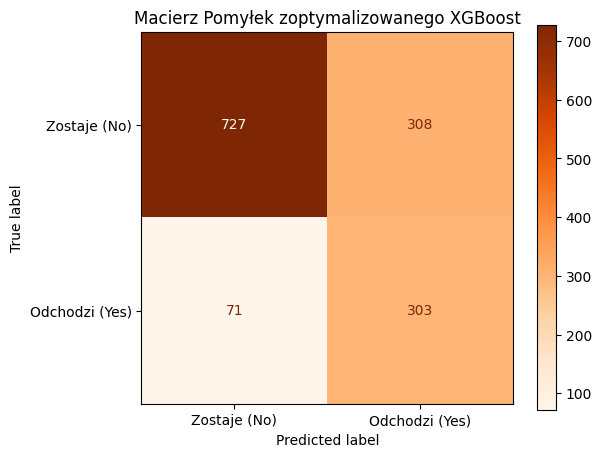

In [10]:
# Generowanie raportu z wynikami oraz macierzy pomyłek
ewaluacja_modelu(best_xgb, X_test, y_test)

### Analiza i interpretacja uzyskanych metryk

Wyniki na zbiorze testowym pozwalają na wyciągnięcie następujących wniosków:

1. **Wysoki poziom czułości (Recall):** Model poprawnie identyfikuje większość klientów z grupy ryzyka. Zastosowanie parametru `scale_pos_weight` spełniło swoją funkcję – algorytm kładzie duży nacisk na klasę osób odchodzących, dzięki czemu nie ignoruje jej mimo asymetrii w zbiorze.
2. **Porównanie z siecią neuronową:** W przeciwieństwie do sieci MLP, która przy próbach balansowania klas stawała się niestabilna i generowała zbyt dużą liczbę fałszywych alarmów, XGBoost utrzymuje stabilną wartość F1-Score. Wzrost czułości nie spowodował całkowitego załamania precyzji modelu.
3. **Charakterystyka macierzy pomyłek:** Rozkład błędów jest uzasadniony ekonomicznie. Model częściej popełnia błąd typu False Positive (błędne wskazanie, że lojalny klient odejdzie) niż False Negative (przeoczenie klienta odchodzącego). W kontekście telekomunikacji koszt zaoferowania drobnej zniżki utrzymawczej lojalnemu klientowi jest znacznie niższy niż koszt utraty klienta na rzecz konkurencji.

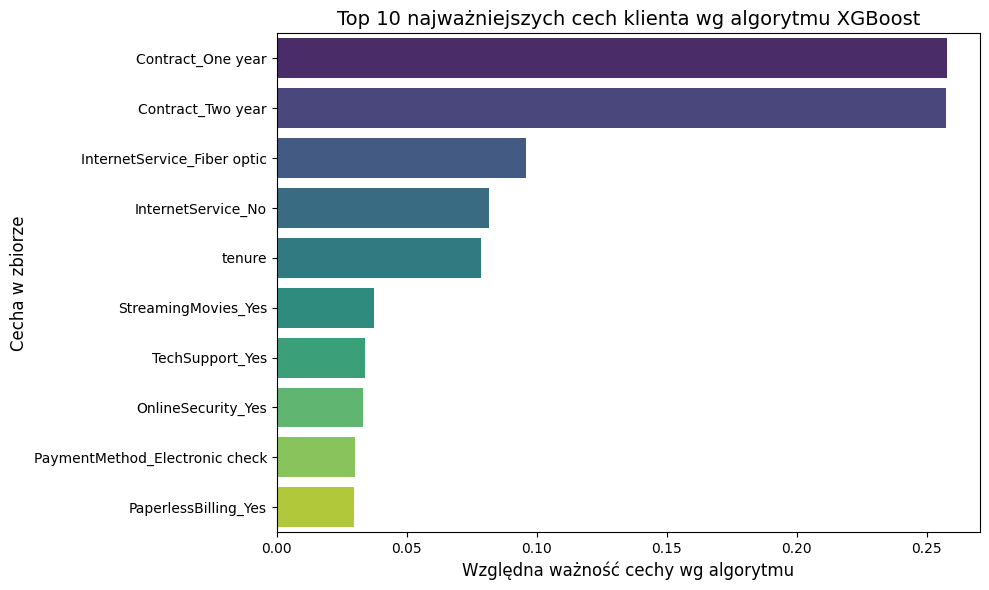

In [11]:
# Wykres najważniejszych cech według algorytmu XGBoost
wizualizuj_waznosc_cech(best_xgb, features)

### Podsumowanie działania modelu XGBoost

Algorytm XGBoost okazał się efektywnym narzędziem do analizy problemu odpływu klientów na tym zbiorze danych. Sekwencyjny proces uczenia pozwolił na poprawne wyznaczenie nieliniowych granic decyzyjnych bez popadania w zjawisko przeuczenia (overfittingu).

Wykres ważności cech jednoznacznie wskazuje, że kluczowymi czynnikami wpływającymi na decyzję o rezygnacji z usług są **staż klienta w firmie (`tenure`)** oraz posiadanie **umowy odnawianej co miesiąc (`Contract_Month-to-month`)**. Z punktu widzenia biznesu oznacza to, że nowi klienci bez długoterminowych zobowiązań kontraktowych stanowią grupę najwyższego ryzyka i to do nich powinny być kierowane w pierwszej kolejności działania retencyjne. Uzyskane wyniki stabilnie realizują postawione cele analityczne i potwierdzają początkową hipotezę badawczą.